# Descriptive statistics + PCA

Python translation of `2_desc_PCA.Rmd`. Loads the per-approach parquet written by `1_prepare.ipynb`, builds a Likert summary table and diverging-bar plots for the outcomes, and runs a PCA with the factor controls projected as supplementary variables (mean coordinate of each level).

R uses `gtsummary`/`gglikert`/`FactoMineR`/`factoextra` for styling and `quali.sup` projection. The Python version uses `pandas`/`matplotlib`/`sklearn`: figures are functionally equivalent but not pixel-identical with the R output.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

os.makedirs('output/desc', exist_ok=True)
os.makedirs('output/acp', exist_ok=True)

## Load

In [2]:
approach = 'replic_830'   # replic_830 / replic_1077 / own_1215

paths = {
    'replic_830':  '../data/data2004_830.parquet',
    'replic_1077': '../data/data2004_1077.parquet',
    'own_1215':    '../data/data2004_1215.parquet',
}
data2004 = pd.read_parquet(paths[approach])
print(f'{approach}: {data2004.shape}')

replic_830: (4, 62)


In [3]:
q2_vars = ['clseusa']
q3_vars = ['ambornin', 'amcit', 'amlived', 'amenglsh', 'amchrstn', 'amgovt', 'amfeel']
q4_vars = ['amcitizn', 'amshamed', 'belikeus', 'ambetter', 'ifwrong']
q5_vars = ['proudsss', 'proudgrp', 'proudpol', 'prouddem', 'proudeco',
           'proudspt', 'proudart', 'proudhis', 'proudmil', 'proudsci']

if approach == 'own_1215':
    q2_vars = ['clsetown', 'clsestat', 'clseusa', 'clsenoam']
    q3_vars = q3_vars + ['amancstr']
    q4_vars = q4_vars + ['amsports', 'lessprd']

q2_vars_f = [v + '_f' for v in q2_vars]
q3_vars_f = [v + '_f' for v in q3_vars]
q4_vars_f = [v + '_f' for v in q4_vars]
q5_vars_f = [v + '_f' for v in q5_vars]

q2_vars_n = [v + '_n' for v in q2_vars]
q3_vars_n = [v + '_n' for v in q3_vars]
q4_vars_n = [v + '_n' for v in q4_vars]
q5_vars_n = [v + '_n' for v in q5_vars]

f_outcomes = q2_vars_f + q3_vars_f + q4_vars_f + q5_vars_f
n_outcomes = q2_vars_n + q3_vars_n + q4_vars_n + q5_vars_n

## Variable labels

Reconstructed here because pandas has no `labelled::set_variable_labels` equivalent — the `_f` columns in the parquet only carry their Likert category labels, not the question wording.

In [4]:
LABELS = {
    'clseusa':  'America',
    'ambornin': 'To have been born in America',
    'amcit':    'To have American citizenship',
    'amlived':  "To have lived in America for most of one's life",
    'amenglsh': 'To be able to speak English',
    'amchrstn': 'To be a Christian',
    'amgovt':   "To respect America's political institutions and laws",
    'amfeel':   'To feel American',
    'amcitizn': 'I would rather be a citizen of America than of any other country in the world',
    'belikeus': 'The world would be a better place if people from other countries were more like the Americans',
    'ambetter': 'Generally speaking, America is a better country than most other countries',
    'ifwrong':  'People should support their country even if their country is in the wrong',
    'amshamed': 'There are some things about America today that make me feel ashamed of America',
    'prouddem': 'The way democracy works',
    'proudpol': 'Its political influence in the world',
    'proudeco': "America's economic achievements",
    'proudsss': 'Its social security system',
    'proudsci': 'Its scientific and technological achievements',
    'proudspt': 'Its achievements in sports',
    'proudart': 'Its achievements in the arts & literature',
    'proudmil': "America's armed forces",
    'proudhis': 'Its history',
    'proudgrp': 'Its fair and equal treatment of all groups in society',
}
if approach == 'own_1215':
    LABELS.update({
        'clsetown': 'Your town or city',
        'clsestat': 'Your state',
        'clsenoam': 'North America',
        'amancstr': 'To have American ancestry',
        'amsports': 'When my country does well in international sports, it makes me proud to be American',
        'lessprd':  'I am often less proud of America than I would like to be',
    })

## Outcomes — Likert table

In [5]:
FULL_LEVELS = ['Not at all', 'Not very much', 'Neutral', 'Somewhat / fairly', 'Very much']

likert_data = data2004.copy()
for c in f_outcomes:
    likert_data[c] = pd.Categorical(
        likert_data[c].astype(object),
        categories=FULL_LEVELS, ordered=False,
    )

In [6]:
def likert_summary(df, vars_):
    rows = []
    for v in vars_:
        cat = df[v]
        n_total = int(cat.notna().sum())
        counts = cat.value_counts().reindex(FULL_LEVELS, fill_value=0)
        pcts = (counts / max(n_total, 1) * 100)
        n_col = v[:-2] + '_n'
        mean_ = df[n_col].mean() if n_col in df.columns else np.nan
        sd_ = df[n_col].std() if n_col in df.columns else np.nan
        row = {
            'variable': v[:-2],
            'label':    LABELS.get(v[:-2], v[:-2]),
        }
        for lvl in FULL_LEVELS:
            row[lvl] = '-' if counts[lvl] == 0 else f'{int(counts[lvl])} ({pcts[lvl]:.1f}%)'
        row['Mean'] = f'{mean_:.1f}' if pd.notna(mean_) else '-'
        row['SD']   = f'{sd_:.1f}'   if pd.notna(sd_)   else '-'
        row['N']    = n_total
        rows.append(row)
    return pd.DataFrame(rows)

likert_table = likert_summary(likert_data, f_outcomes)
likert_table.to_csv('output/desc/likert_table.csv', index=False)
likert_table

,variable,label,Not at all,Not very much,Neutral,Somewhat / fairly,Very much,Mean,SD,N
0,clseusa,America,1 (25.0%),3 (75.0%),-,-,-,1.8,0.5,4
1,ambornin,To have been born in America,1 (25.0%),3 (75.0%),-,-,-,1.8,0.5,4
2,amcit,To have American citizenship,-,2 (50.0%),-,-,2 (50.0%),2.5,0.6,4
3,amlived,To have lived in America for most of one's life,1 (25.0%),2 (50.0%),-,-,1 (25.0%),2.0,0.8,4
4,amenglsh,To be able to speak English,-,1 (25.0%),-,-,3 (75.0%),2.8,0.5,4
5,amchrstn,To be a Christian,3 (75.0%),1 (25.0%),-,-,-,1.2,0.5,4
6,amgovt,To respect America's political institutions an...,-,1 (25.0%),-,-,3 (75.0%),2.8,0.5,4
7,amfeel,To feel American,1 (25.0%),1 (25.0%),-,-,2 (50.0%),2.2,1.0,4
8,amcitizn,I would rather be a citizen of America than of...,1 (25.0%),1 (25.0%),-,2 (50.0%),-,2.8,1.5,4
9,amshamed,There are some things about America today that...,-,-,1 (25.0%),-,3 (75.0%),1.5,1.0,4


## Likert plots

Diverging horizontal stacked bar charts, mimicking `ggstats::gglikert`. Neutral category is split equally on either side of zero.

In [7]:
LIKERT_COLORS = {
    'Not at all':         '#d7191c',
    'Not very much':      '#fdae61',
    'Neutral':            '#ffffbf',
    'Somewhat / fairly':  '#abd9e9',
    'Very much':          '#2c7bb6',
}


def _likert_fracs(df, vars_):
    fracs = {}
    for v in vars_:
        cat = df[v]
        n = max(int(cat.notna().sum()), 1)
        fracs[v] = cat.value_counts().reindex(FULL_LEVELS, fill_value=0) / n
    return pd.DataFrame(fracs).T


def _draw_likert(ax, fracs_df, xlim=(-1, 1)):
    positive = fracs_df[['Somewhat / fairly', 'Very much']].sum(axis=1)
    order = positive.sort_values(ascending=True).index
    fracs_df = fracs_df.loc[order]
    neutral = fracs_df['Neutral'] / 2
    y = np.arange(len(fracs_df))

    # Left half (negative direction)
    ax.barh(y, -neutral, height=0.7, color=LIKERT_COLORS['Neutral'], edgecolor='white')
    ax.barh(y, -fracs_df['Not very much'], height=0.7,
            left=-neutral, color=LIKERT_COLORS['Not very much'], edgecolor='white')
    ax.barh(y, -fracs_df['Not at all'], height=0.7,
            left=-(neutral + fracs_df['Not very much']),
            color=LIKERT_COLORS['Not at all'], edgecolor='white')

    # Right half (positive direction)
    ax.barh(y, neutral, height=0.7, color=LIKERT_COLORS['Neutral'], edgecolor='white')
    ax.barh(y, fracs_df['Somewhat / fairly'], height=0.7,
            left=neutral, color=LIKERT_COLORS['Somewhat / fairly'], edgecolor='white')
    ax.barh(y, fracs_df['Very much'], height=0.7,
            left=(neutral + fracs_df['Somewhat / fairly']),
            color=LIKERT_COLORS['Very much'], edgecolor='white')

    ax.set_yticks(y)
    ax.set_yticklabels([LABELS.get(v[:-2], v[:-2]) for v in fracs_df.index], fontsize=9)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlim(*xlim)
    ticks = [t for t in [-1, -0.5, 0, 0.5, 1] if xlim[0] <= t <= xlim[1]]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{int(abs(t) * 100)}%' for t in ticks])
    return ax

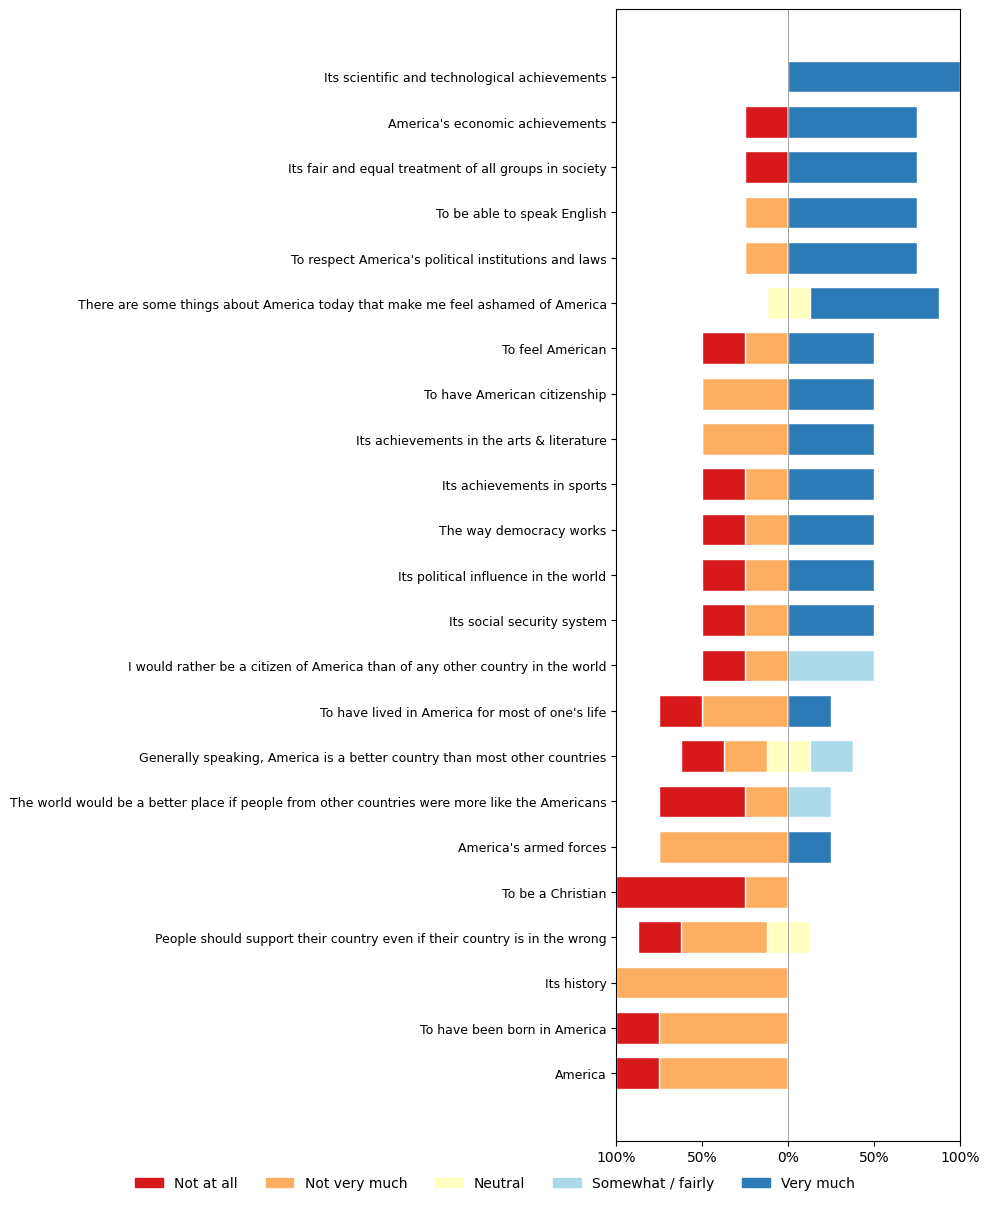

In [8]:
fracs_all = _likert_fracs(likert_data, f_outcomes)
fig, ax = plt.subplots(figsize=(10, max(2, 0.45 * len(fracs_all) + 1.5)))
_draw_likert(ax, fracs_all, xlim=(-1, 1))
handles = [plt.Rectangle((0, 0), 1, 1, color=LIKERT_COLORS[l]) for l in FULL_LEVELS]
fig.legend(handles, FULL_LEVELS, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig('output/desc/likert_plot_2004.png', dpi=300, bbox_inches='tight')
plt.show()

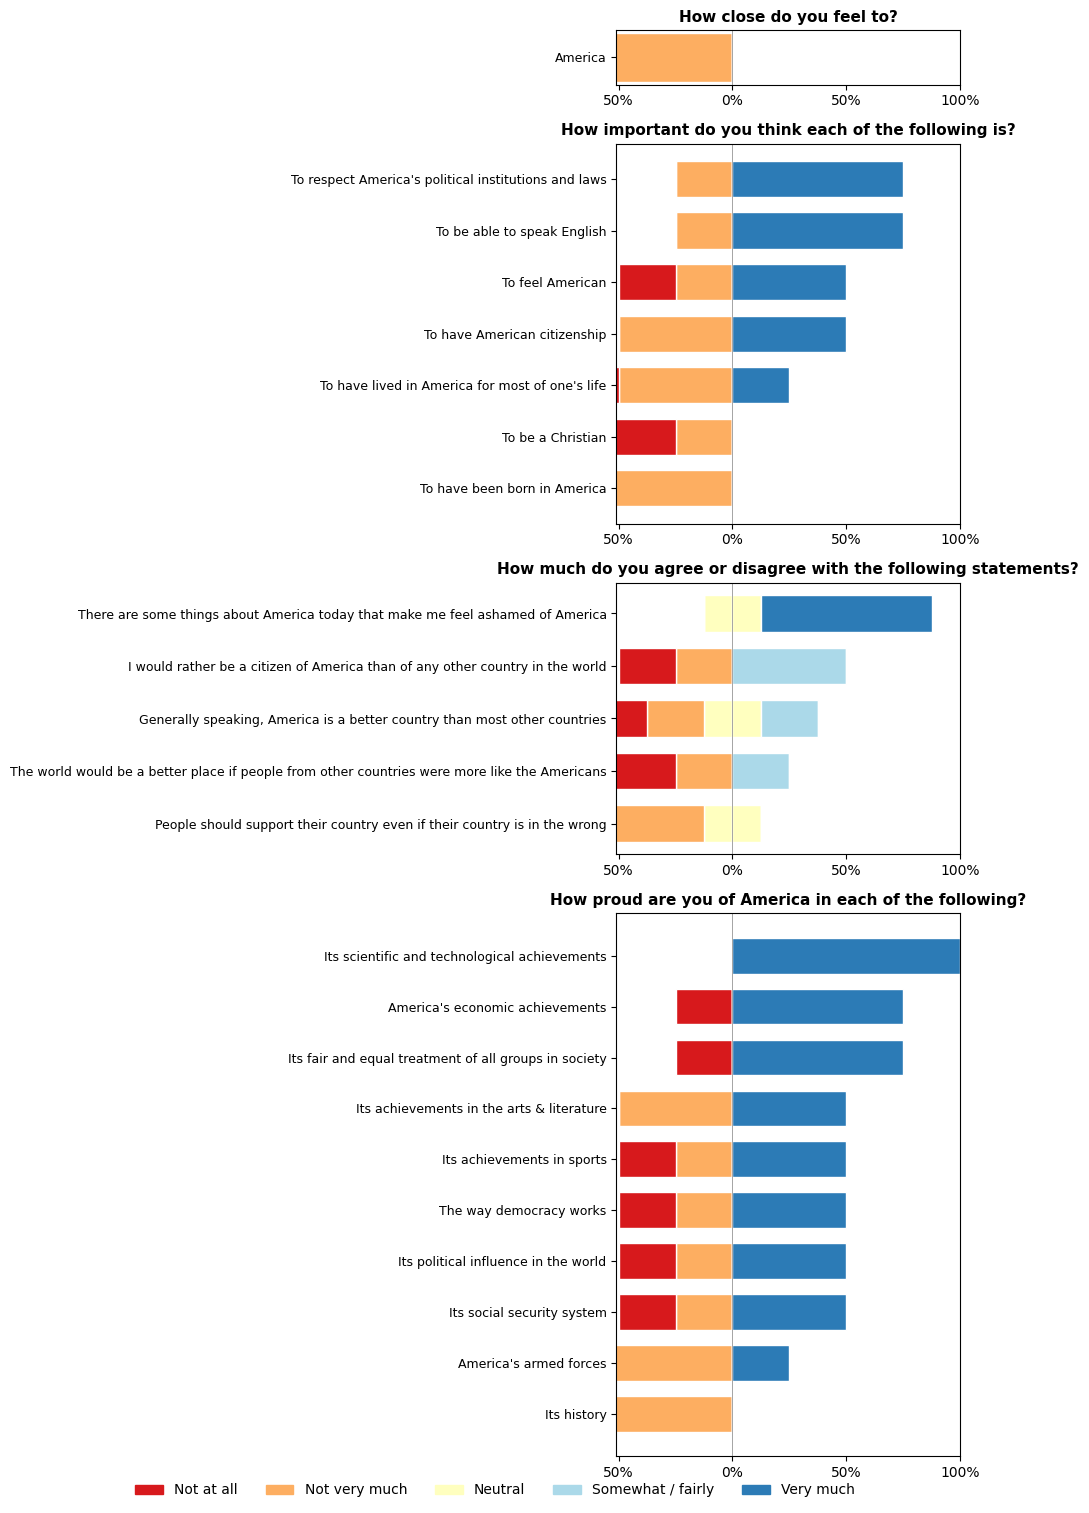

In [10]:
groups = [
    (q2_vars_f, 'How close do you feel to?'),
    (q3_vars_f, 'How important do you think each of the following is?'),
    (q4_vars_f, 'How much do you agree or disagree with the following statements?'),
    (q5_vars_f, 'How proud are you of America in each of the following?'),
]
heights = [max(1, len(g[0])) for g in groups]
fig, axes = plt.subplots(4, 1, figsize=(10, 15), gridspec_kw={'height_ratios': heights})
for ax, (vars_, title) in zip(axes, groups):
    _draw_likert(ax, _likert_fracs(likert_data, vars_), xlim=(-0.51, 1))
    ax.set_title(title, fontweight='bold', fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, color=LIKERT_COLORS[l]) for l in FULL_LEVELS]
fig.legend(handles, FULL_LEVELS, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
fig.savefig('output/desc/likert_plots_2004.png', dpi=300, bbox_inches='tight')
plt.show()

## PCA

PCA on standardized numeric outcomes (`scale.unit = TRUE` in the R). Factor controls are projected as supplementary variables: each level's coordinate is the mean of its members' individual coordinates.

In [11]:
f_controls = ['sex_f', 'race_f', 'born_usa_f', 'party_f', 'religstr_f',
              'reltrad_f', 'region_f', 'realinc2004_f']

X = data2004[n_outcomes].copy()
X.columns = [c[:-2] for c in X.columns]
mask = X.notna().all(axis=1)
X = X.loc[mask]
controls_df = data2004.loc[mask, f_controls].copy()
controls_df.columns = [c[:-2] for c in controls_df.columns]

X_z = (X - X.mean()) / X.std(ddof=1)
ncp = 10
pca = PCA(n_components=ncp)
ind_coord = pd.DataFrame(
    pca.fit_transform(X_z),
    columns=[f'Dim.{i + 1}' for i in range(ncp)],
    index=X.index,
)
expl_var_pct = pca.explained_variance_ratio_ * 100
print('Explained variance (%) per component:')
print(np.round(expl_var_pct, 2))

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [12]:
# FactoMineR-style variable coordinates, cos2, contributions
eigvals = pca.explained_variance_
var_coord = pd.DataFrame(
    pca.components_.T * np.sqrt(eigvals),
    index=X.columns, columns=[f'Dim.{i + 1}' for i in range(ncp)],
)
var_cos2 = var_coord ** 2
var_contrib = var_cos2.div(eigvals, axis=1) * 100
print('Top 10 contributors to component 1:')
print(var_contrib['Dim.1'].sort_values(ascending=False).head(10).round(2))

AttributeError: 'PCA' object has no attribute 'explained_variance_'

In [ ]:
# Supplementary qualitative projection (mean coord per level)
rows = []
for c in controls_df.columns:
    for lvl in controls_df[c].dropna().unique():
        sel = controls_df[c] == lvl
        if sel.sum() == 0:
            continue
        mean_ = ind_coord.loc[sel].mean()
        rows.append({'variable': c, 'level': lvl, **mean_.to_dict()})
quali_coord = pd.DataFrame(rows).set_index(['variable', 'level'])
print(quali_coord.head(15).round(3))

### Screeplot

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, ncp + 1), expl_var_pct,
       color='lightskyblue', edgecolor='cornflowerblue', width=0.7)
for i, v in enumerate(expl_var_pct):
    ax.text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', color='darkblue', fontsize=9)
ax.set_xlabel('Components')
ax.set_ylabel('% of explained variance')
ax.set_xticks(range(1, ncp + 1))
ax.set_ylim(top=max(expl_var_pct) * 1.15)
plt.tight_layout()
fig.savefig('output/acp/screeplot.png', dpi=300)
plt.show()

### Contributions table

In [ ]:
contrib_tbl = var_contrib.copy()
contrib_tbl.index.name = 'Variables'
contrib_tbl.columns = [str(i + 1) for i in range(ncp)]
contrib_tbl.to_csv('output/acp/contrib_axes.csv')
contrib_tbl.style.format(precision=2).background_gradient(cmap='Oranges', axis=0)

### Heatmaps

In [ ]:
def corrplot(matrix, title, vmin, vmax, cmap, filename=None):
    fig, ax = plt.subplots(figsize=(max(8, matrix.shape[1] * 0.4),
                                    max(4, matrix.shape[0] * 0.5)))
    im = ax.imshow(matrix.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(matrix.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(matrix.index, fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=300)
    return fig, ax

In [ ]:
corrplot(
    (var_contrib / 100).T,
    "Variable contributions to the components' variance",
    vmin=0, vmax=1, cmap='Oranges',
    filename='output/acp/contrib_axes.png',
)
plt.show()

corrplot(
    var_coord.iloc[:, :5].T,
    'Correlation of outcome variables with the components',
    vmin=-1, vmax=1, cmap='RdBu_r',
    filename='output/acp/corr_outc_axes.png',
)
plt.show()

if not quali_coord.empty:
    qmat = quali_coord.iloc[:, :5].copy()
    qmat.index = [f'{v}={l}' for v, l in qmat.index]
    corrplot(
        qmat.T,
        'Correlation of control variables with the components',
        vmin=-1, vmax=1, cmap='RdBu_r',
        filename='output/acp/corr_reg_axes.png',
    )
    plt.show()

corrplot(
    var_cos2.iloc[:, :5].T,
    "Quality of outcome variables' representation",
    vmin=0, vmax=1, cmap='Oranges',
    filename='output/acp/qual_rep_outc.png',
)
plt.show()

### Variable projection (correlation circle)

In [ ]:
top12 = var_contrib[['Dim.1', 'Dim.2']].sum(axis=1).sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color='#636363')
ax.axhline(0, color='#636363', linestyle='--', alpha=0.5)
ax.axvline(0, color='#636363', linestyle='--', alpha=0.5)

contribs = var_contrib.loc[top12, ['Dim.1', 'Dim.2']].sum(axis=1)
norm = plt.Normalize(vmin=contribs.min(), vmax=contribs.max())
cmap = plt.get_cmap('coolwarm')
for v in top12:
    x, y = var_coord.loc[v, 'Dim.1'], var_coord.loc[v, 'Dim.2']
    ax.arrow(0, 0, x, y, head_width=0.02,
             color=cmap(norm(contribs[v])), length_includes_head=True)
    ax.text(x * 1.1, y * 1.1, v, fontsize=8, ha='center')

ax.set_xlabel(f'Component 1 ({expl_var_pct[0]:.2f}%)')
ax.set_ylabel(f'Component 2 ({expl_var_pct[1]:.2f}%)')
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_title('Variable projections on components 1 and 2')
plt.tight_layout()
fig.savefig('output/acp/proj_var.png', dpi=300)
plt.show()

### Individual projection coloured by partisanship

In [ ]:
party = controls_df['party']
palette = {'Democrat': 'cornflowerblue', 'Independent': 'lightgreen', 'Republican': 'coral1'}

fig, ax = plt.subplots(figsize=(8, 8))
for lvl, col in palette.items():
    sel = party == lvl
    if sel.any():
        ax.scatter(ind_coord.loc[sel, 'Dim.1'], ind_coord.loc[sel, 'Dim.2'],
                   alpha=0.7, c=col, s=20, label=lvl)
ax.axhline(0, color='#636363', linestyle='--')
ax.axvline(0, color='#636363', linestyle='--')
ax.set_xlabel(f'Component 1 ({expl_var_pct[0]:.2f}%)')
ax.set_ylabel(f'Component 2 ({expl_var_pct[1]:.2f}%)')
ax.set_title('Individual projections on components 1 and 2')
ax.legend(title='Partisanship')
plt.tight_layout()
fig.savefig('output/acp/proj_ind.png', dpi=300)
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
fig.savefig('output/acp/proj_ind_zoom.png', dpi=300)
plt.show()